In [3]:
%run CleanData.ipynb

# ==================== IMPORTS ====================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [4]:
# ==================== TRAIN MODEL ====================
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [5]:
# ==================== PREDICTION ====================
y_pred = rf_model.predict(X_test)

In [6]:
# ==================== EVALUATE MODEL ====================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.9541587711163972
Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97     18952
           1       0.98      0.59      0.73       556
           2       0.98      0.87      0.93      1448
           3       0.83      0.60      0.70       162
           4       0.99      0.94      0.97      1608
           5       0.98      0.74      0.85      2077

    accuracy                           0.95     24803
   macro avg       0.95      0.79      0.86     24803
weighted avg       0.96      0.95      0.95     24803

Confusion Matrix:
 [[18917     8     4     3     2    18]
 [  227   326     0     0     1     2]
 [  157     0  1265    16     4     6]
 [   53     0    12    97     0     0]
 [   83     0     3     0  1518     4]
 [  531     0     1     1     1  1543]]


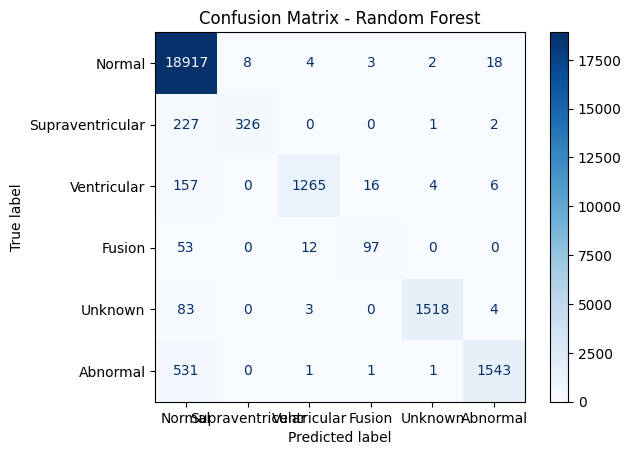

In [8]:
# ==================== PLOT CONFUSION MATRIX ====================
label_names = ['Normal', 'Supraventricular', 'Ventricular', 'Fusion', 'Unknown', 'Abnormal']
cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

C:\Users\plui0\AppData\Local\Temp\ipykernel_35132\3150444045.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('Set2', len(rf_model.classes_))


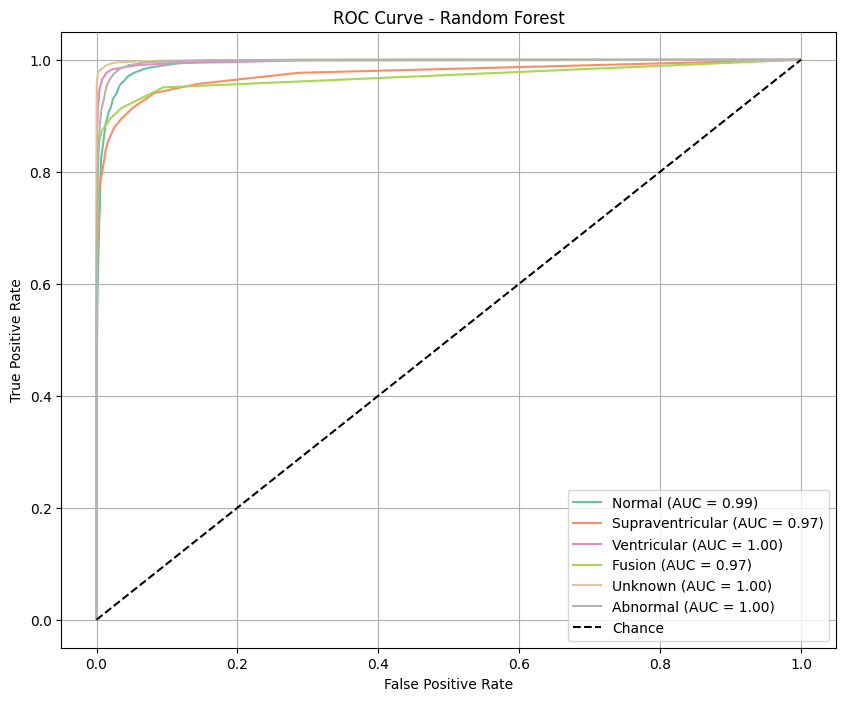

In [9]:
# ==================== ROC & AUC ====================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# Binarize the output labels
y_test_bin = label_binarize(y_test, classes=rf_model.classes_)
y_pred_prob = rf_model.predict_proba(X_test)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}
for i in range(len(rf_model.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap('Set2', len(rf_model.classes_))
for i in range(len(rf_model.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"{label_names[i]} (AUC = {roc_auc[i]:.2f})", color=colors(i))

plt.plot([0, 1], [0, 1], 'k--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
